# Part 3: Analysis and Thermodynamic Properties 📈

Welcome to the final notebook\! In the last section, you ran a successful simulation of liquid Argon and confirmed that it reached thermal equilibrium. Now, we'll analyze the data you generated to calculate a real, macroscopic thermodynamic property: the **constant volume heat capacity ($C\_v$)**.

This process is a perfect example of how computational chemistry acts as a bridge between the microscopic world of atomic motion and the macroscopic world of thermodynamics that you're learning about in your lectures.

First, let's import the libraries we'll need for analysis.

In [1]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from ase import units

-----

## 3.1 Loading the Simulation Data

The `MDLogger` we used in the previous notebook saved all the key properties of our system at regular intervals into the file `md.log`. Let's load that data into our notebook using NumPy.

In [58]:
# Load the data from the log file, skipping the header row
log_data = np.loadtxt('md.log', skiprows=1)

# Let's assign columns to named variables for clarity
# Column indices: 0=Time(ps), 4=Temp(K), 1=E_tot(eV)
time = log_data[:, 0]
temperature = log_data[:, 4]
total_energy = log_data[:, 1]

print("Log data loaded successfully!")

Log data loaded successfully!


-----

## 3.2 Visualizing System Energy & Determining Equilibration Time

In the last notebook, we plotted temperature to check for equilibration. Plotting the **total energy** is another excellent way to do this. We're looking for the point where the energy stops decreasing and starts fluctuating around a stable average. This stable region is the "production" phase, and it's the only part of the data we should use for calculating properties.


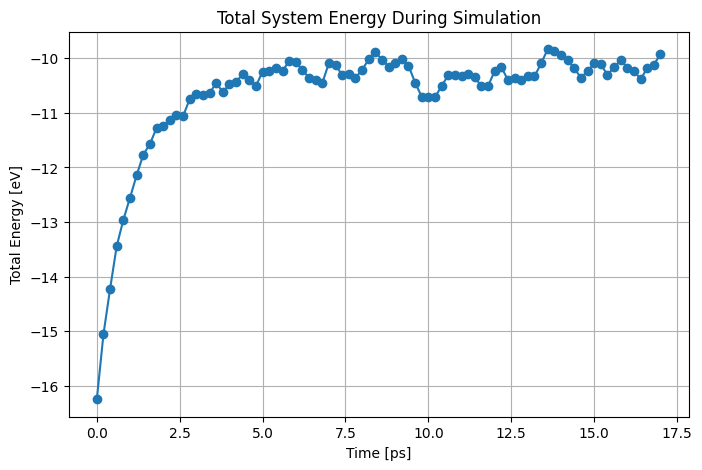

In [59]:
# Plotting the Total Energy
plt.figure(figsize=(8, 5))
plt.plot(time, total_energy, 'o-')
plt.title('Total System Energy During Simulation')
plt.xlabel('Time [ps]')
plt.ylabel('Total Energy [eV]')
plt.grid(True)
plt.show()

### **📋 Reporting Task 5**

Based on the **Total Energy vs. Time** plot above:

1.  Save a copy of the plot for your workbook.
2.  Estimate the time (in fs) at which the system appears to be fully equilibrated. We will use this value to slice our data for the final calculation.


In [5]:
# Answer goes here

-----

## 3.3 Calculating Heat Capacity from Fluctuations

### The Theory

In statistical mechanics, there's a beautiful connection between macroscopic properties and the microscopic fluctuations of a system at equilibrium. The constant volume heat capacity ($C\_v$) can be calculated from the **variance** (the square of the standard deviation, $\\sigma\_E^2$) of the total energy ($E$) using the following formula:

$$C_v = \frac{\langle E^2 \rangle - \langle E \rangle^2}{k_B T^2} = \frac{\sigma_E^2}{k_B T^2}$$

Here, $k\_B$ is the Boltzmann constant and $T$ is the average temperature. We have all of this information in our log file\!

### The Calculation

Now, let's write the code to perform this calculation. We'll start our analysis after the equilibration time you determined previously (is a value around 2 ps is a good choice?).


In [ ]:
# --- Calculation of Cv ---

# 1. Define the equilibration time (in ps) based on your plot
equilibration_time = 2.0 

# Find the index where the production phase starts
start_index = np.where(time >= equilibration_time)[0][0]

# 2. Slice the arrays to use only the production data
production_energy = total_energy[start_index:]
production_temperature = temperature[start_index:]

# 3. Calculate the necessary averages and the variance
avg_temp = np.mean(production_temperature)
energy_variance = np.var(production_energy) # variance is std**2

# 4. Apply the formula for Cv (in eV/K)
# We use the ase.units object for the Boltzmann constant (kB)
cv_eV_per_K = energy_variance*0.01 / (units.kB * avg_temp**2)

# 5. Convert to standard molar units (J / K*mol)
# Get the number of atoms in the system
num_atoms = 2048 # We know this from our setup
# Convert from (eV/K) per system to (J/K) per mole of atoms
# 1 eV = 1.602e-19 J; Avogadro's number = 6.022e23
cv_J_per_K_mol = cv_eV_per_K * units.mol / units.J

# The experimental value is ~25 J / K*mol
print(f"Average Temperature: {avg_temp:.2f} K")
print(f"Energy Variance: {energy_variance:.6f} eV^2")
print(f"Calculated Cv: {cv_J_per_K_mol:.2f} J / (K*mol)")
print(f"Experimental Cv: ~20 J / (K*mol)")

Average Temperature: 98.38 K
Energy Variance: 0.041042 eV^2
Calculated Cv: 47.48 J / (K*mol)
Experimental Cv: ~20 J / (K*mol)



-----

### **📋 Reporting Task 6**

For the final part of your workbook, please provide:

1.  Your final calculated value for the constant volume heat capacity ($C\_v$) in J K⁻¹ mol⁻¹.
2.  A short paragraph comparing your result to the experimental value. Compare your simulations to that reported by Nichele et al. (2017) 10.1016/j.molliq.2017.03.120 and provide **two** potential reasons why your simulated value might be different.

# Answer goes here.
